# Task 6 — Correlation heatmap

**Problem-statement step:** *Generate a heatmap to illustrate the correlation between different pairs of variables.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Locate the raw data whether the notebook is opened from its own folder
# (notebooks/) or from the project root.
import os
_CANDIDATES = ["marketing_data.csv", "../marketing_data.csv",
               os.path.join(os.path.dirname(os.getcwd()), "marketing_data.csv")]
DATA_PATH = next((p for p in _CANDIDATES if os.path.exists(p)), "marketing_data.csv")
print("Using data file:", DATA_PATH)

Using data file: ../marketing_data.csv


In [2]:
REFERENCE_YEAR = 2015  # data compiled just after the last enrolment (Jun 2014)
SPEND_COLS = ["MntWines", "MntFruits", "MntMeatProducts",
              "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
CHANNEL_COLS = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]

def load_and_prepare(path=DATA_PATH, engineer=True):
    """Load -> fix dtypes -> clean categories -> impute income -> features."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()                     # ' Income ' -> 'Income'
    if not pd.api.types.is_numeric_dtype(df["Income"]):     # '$84,835.00' -> float
        df["Income"] = (df["Income"].astype("string")
                        .str.replace(r"[\$,]", "", regex=True).str.strip().astype(float))
    df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%m/%d/%y")
    df["Marital_Status"] = df["Marital_Status"].replace(
        {"Alone": "Single", "YOLO": "Single", "Absurd": "Single"})
    df["Income"] = df.groupby(["Education", "Marital_Status"])["Income"].transform(
        lambda s: s.fillna(s.median()))
    df["Income"] = df["Income"].fillna(df["Income"].median())
    if engineer:
        df["Kids"] = df["Kidhome"] + df["Teenhome"]
        df["Age"] = REFERENCE_YEAR - df["Year_Birth"]
        df["Total_Spending"] = df[SPEND_COLS].sum(axis=1)
        df["Total_Purchases"] = df[CHANNEL_COLS].sum(axis=1)
        df["Total_Accepted_Cmp"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
                                       "AcceptedCmp4", "AcceptedCmp5"]].sum(axis=1)
        df["Has_Child"] = (df["Kids"] > 0).astype(int)
        df["Is_US"] = (df["Country"] == "US").astype(int)
    return df

def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return q1 - k * (q3 - q1), q3 + k * (q3 - q1)

def treat_outliers(df):
    """Drop impossible ages and winsorise heavy-tailed continuous columns."""
    df = df[df["Age"] <= 100].copy()
    for col in ["Income", "Total_Spending", "Total_Purchases", "NumWebVisitsMonth"]:
        lo, hi = iqr_bounds(df[col])
        df[col] = df[col].clip(lo, hi)
    return df

In [3]:
df = treat_outliers(load_and_prepare())
df["Education_Ordinal"] = df["Education"].map(
    {"Basic": 0, "2n Cycle": 1, "Graduation": 2, "Master": 3, "PhD": 4})

## 1. Build the correlation matrix on the meaningful numeric variables

In [4]:
focus = ["Age", "Income", "Kids", "Kidhome", "Teenhome", "Recency",
         "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
         "MntSweetProducts", "MntGoldProds", "NumDealsPurchases",
         "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
         "NumWebVisitsMonth", "Total_Spending", "Total_Purchases",
         "Total_Accepted_Cmp", "Response", "Complain", "Education_Ordinal"]
corr = df[focus].corr(numeric_only=True)
corr.shape

(23, 23)

## 2. Heatmap

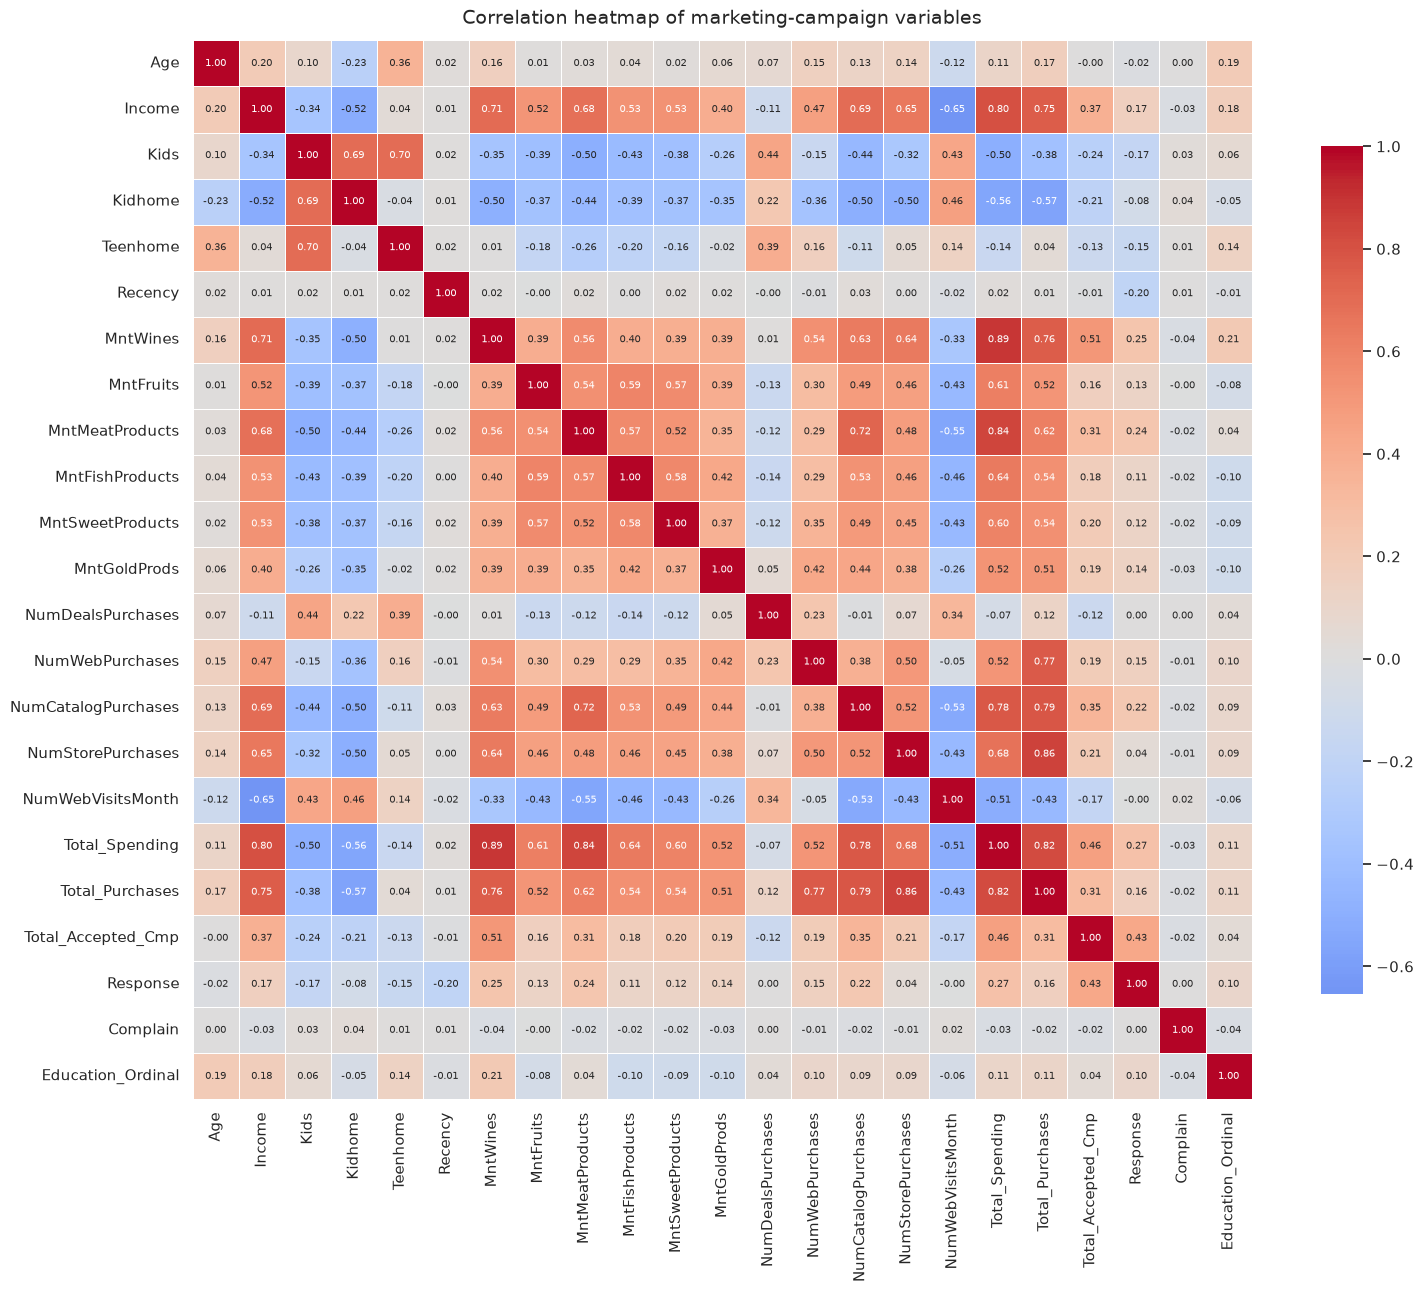

In [5]:
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation heatmap of marketing-campaign variables", fontsize=14, pad=12)
fig.tight_layout(); plt.show()

## 3. Strongest correlated variable pairs

In [6]:
mask = np.triu(np.ones(corr.shape, dtype=bool))
pairs = (corr.mask(mask).stack().reset_index()
         .rename(columns={"level_0": "Var1", "level_1": "Var2", 0: "corr"}))
pairs["abs"] = pairs["corr"].abs()
pairs.sort_values("abs", ascending=False).head(10)[["Var1", "Var2", "corr"]]

,Var1,Var2,corr
397,Total_Spending,MntWines,0.891741
429,Total_Purchases,NumStorePurchases,0.855399
399,Total_Spending,MntMeatProducts,0.842638
431,Total_Purchases,Total_Spending,0.821196
392,Total_Spending,Income,0.804015
428,Total_Purchases,NumCatalogPurchases,0.785639
405,Total_Spending,NumCatalogPurchases,0.778418
427,Total_Purchases,NumWebPurchases,0.765720
420,Total_Purchases,MntWines,0.756494
415,Total_Purchases,Income,0.754918


### Conclusion
`Income`, `Total_Spending` and catalog/store purchases move together strongly (affluent customers buy more across every channel), while the number of children correlates negatively with spend and positively with web visits and deal purchases.